In [1]:
%matplotlib inline
# Cell 1 — parameters (swap polity_id or variable here)
POLITY_ID  = 14941          # Kingdom of Egypt 1950–1952
VARIABLE   = 'dis_m3_pyr'  # annual discharge
VAR_LABEL  = 'Annual Discharge (m³/yr)'

In [2]:
# Cell 2 — imports and connection
import sys
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')
warnings.filterwarnings('ignore', category=UserWarning, module='pandas')
warnings.filterwarnings('ignore', category=DeprecationWarning)
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from shapely.geometry import box as shapely_box
from pathlib import Path

sys.path.insert(0, '../../..')
from scripts.shared.db_utils import db_connect
import scripts.shared.db_utils as _dbu

conn = db_connect()
print('Connected:', conn.execute('SELECT current_database()').fetchone())

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUT}')

CMAP         = 'Blues'
POLITY_COLOR = '#e63946'
POLITY_LW    = 2.0

Connected: ('cedop',)
Output dir: /Users/karlg/Documents/repos/_edops/output/edop


In [3]:
# Cell 3 — load polity geometry
polity = gpd.read_postgis(
    f"SELECT id, name, fromyear, toyear, geom FROM gaz.clio_polities WHERE id = {POLITY_ID}",
    conn, geom_col='geom'
)
print(polity[['id','name','fromyear','toyear']].to_string())
bbox = polity.total_bounds  # minx, miny, maxx, maxy
minx, miny, maxx, maxy = bbox
print(f'Bbox: {bbox}')
polity_union = polity.geometry.union_all()

      id              name  fromyear  toyear
0  14941  Kingdom of Egypt      1950    1952
Bbox: [24.7201004  21.95054436 36.95799637 31.65752602]


In [4]:
# Cell 4 — load L8 basins intersecting polity, with discharge
gdf_l8 = gpd.read_postgis(
    f"""
    SELECT b.hybas_id, b.{VARIABLE}, b.geom
    FROM public.basin08 b
    WHERE ST_Intersects(b.geom, (SELECT geom FROM gaz.clio_polities WHERE id = {POLITY_ID}))
      AND b.{VARIABLE} != -9999
    """,
    conn, geom_col='geom'
).rename_geometry('geometry')
print(f'L8 basins: {len(gdf_l8)}, discharge range: {gdf_l8[VARIABLE].min():.1f} – {gdf_l8[VARIABLE].max():.1f}')

L8 basins: 1404, discharge range: 0.0 – 3217.1


In [5]:
# Cell 5 — load L6 basins for inset
gdf_l6 = gpd.read_postgis(
    f"""
    SELECT b.hybas_id, b.{VARIABLE}, b.geom
    FROM public.basin06 b
    WHERE ST_Intersects(b.geom, (SELECT geom FROM gaz.clio_polities WHERE id = {POLITY_ID}))
      AND b.{VARIABLE} != -9999
    """,
    conn, geom_col='geom'
)
print(f'L6 basins: {len(gdf_l6)}, discharge range: {gdf_l6[VARIABLE].min():.1f} – {gdf_l6[VARIABLE].max():.1f}')

L6 basins: 110, discharge range: 0.0 – 3217.1


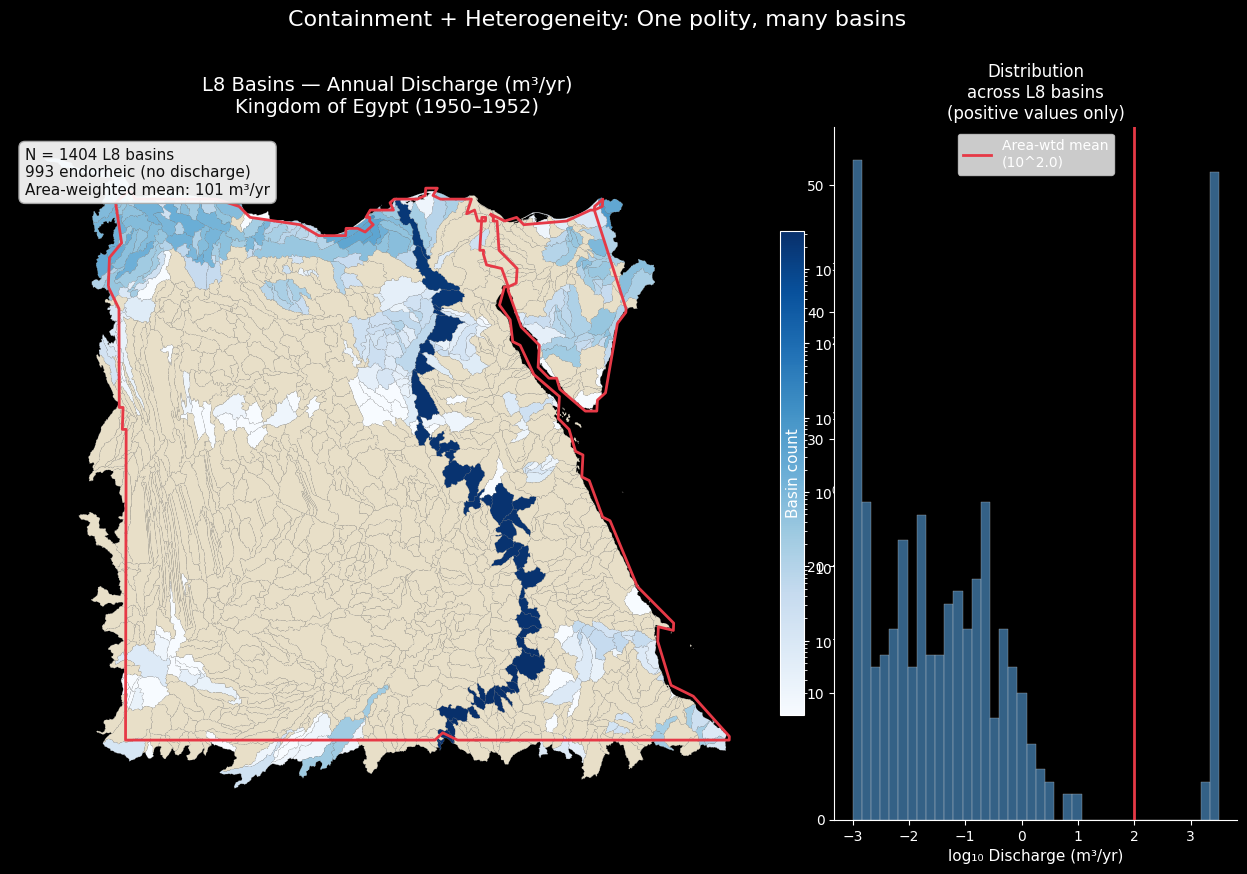

In [6]:
# Cell 6 — Figure 1: containment + heterogeneity (L8 primary, histogram panel)
gdf_l8 = gdf_l8.copy()
gdf_l8['plot_val'] = gdf_l8[VARIABLE].where(gdf_l8[VARIABLE] > 0)

pos_vals = gdf_l8['plot_val'].dropna()
norm = LogNorm(vmin=pos_vals.quantile(0.02), vmax=pos_vals.quantile(0.98))

area_wt_mean = np.average(gdf_l8[VARIABLE], weights=gdf_l8.geometry.area)
n_basins     = len(gdf_l8)
n_zero       = (gdf_l8[VARIABLE] == 0).sum()

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1], wspace=0.05)

ax_main = fig.add_subplot(gs[0])
gdf_l8.plot(
    column='plot_val', ax=ax_main, cmap=CMAP, norm=norm,
    linewidth=0.1, edgecolor='#cccccc',
    missing_kwds={'color': '#e8dfc8', 'edgecolor': '#cccccc', 'label': 'No discharge (endorheic)'}
)
polity.boundary.plot(ax=ax_main, color=POLITY_COLOR, linewidth=POLITY_LW)
ax_main.set_title(
    f'L8 Basins — {VAR_LABEL}\n'
    f'{polity.iloc[0]["name"]} ({polity.iloc[0]["fromyear"]}–{polity.iloc[0]["toyear"]})',
    fontsize=14, pad=10
)
ax_main.set_axis_off()
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_main, fraction=0.03, pad=0.02)
cbar.set_label(VAR_LABEL, fontsize=11)
ax_main.text(
    0.02, 0.97,
    f'N = {n_basins} L8 basins\n{n_zero} endorheic (no discharge)\nArea-weighted mean: {area_wt_mean:,.0f} m³/yr',
    transform=ax_main.transAxes, fontsize=11, va='top', color='#111111',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#aaaaaa', alpha=0.92)
)

ax_hist = fig.add_subplot(gs[1])
log_vals = np.log10(pos_vals)
log_mean = np.log10(area_wt_mean) if area_wt_mean > 0 else None
ax_hist.hist(log_vals, bins=40, color='steelblue', alpha=0.75, edgecolor='#cccccc', linewidth=0.3)
if log_mean:
    ax_hist.axvline(log_mean, color=POLITY_COLOR, linewidth=2,
                    label=f'Area-wtd mean\n(10^{log_mean:.1f})')
    ax_hist.legend(fontsize=10)
ax_hist.set_xlabel('log₁₀ Discharge (m³/yr)', fontsize=11)
ax_hist.set_ylabel('Basin count', fontsize=11)
ax_hist.set_title('Distribution\nacross L8 basins\n(positive values only)', fontsize=12)
ax_hist.spines[['top','right']].set_visible(False)

fig.suptitle('Containment + Heterogeneity: One polity, many basins', fontsize=16, y=1.01)
plt.savefig(OUT / 'fig1_containment_heterogeneity.png', dpi=300, bbox_inches='tight')
print('Saved fig1')

In [7]:
# Cell 7 — load HYDE cells intersecting polity bbox
gdf_hyde = gpd.read_postgis(
    f"""
    SELECT cell_id, area_km2, geom
    FROM temporal.hyde_cells
    WHERE ST_Intersects(geom, ST_MakeEnvelope({minx}, {miny}, {maxx}, {maxy}, 4326))
    """,
    conn, geom_col='geom'
)
print(f'HYDE cells in bbox: {len(gdf_hyde)}')

HYDE cells in bbox: 15331


In [8]:
# Cell 8 — build LMR cell polygons from 2°×2° grid points
df_lmr = pd.read_sql(
    f"""
    SELECT id, lat, lon
    FROM temporal.lmr_climate
    WHERE lon BETWEEN {minx - 2} AND {maxx + 2}
      AND lat BETWEEN {miny - 2} AND {maxy + 2}
    """,
    conn
)
df_lmr['geometry'] = df_lmr.apply(
    lambda r: shapely_box(r.lon - 1.0, r.lat - 1.0, r.lon + 1.0, r.lat + 1.0), axis=1
)
gdf_lmr = gpd.GeoDataFrame(df_lmr, geometry='geometry', crs='EPSG:4326')
print(f'LMR cells in extended bbox: {len(gdf_lmr)}')

/var/folders/f9/r5mr431d23zcpktsjz_xjxt40000gn/T/ipykernel_79105/310470107.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lmr = pd.read_sql(


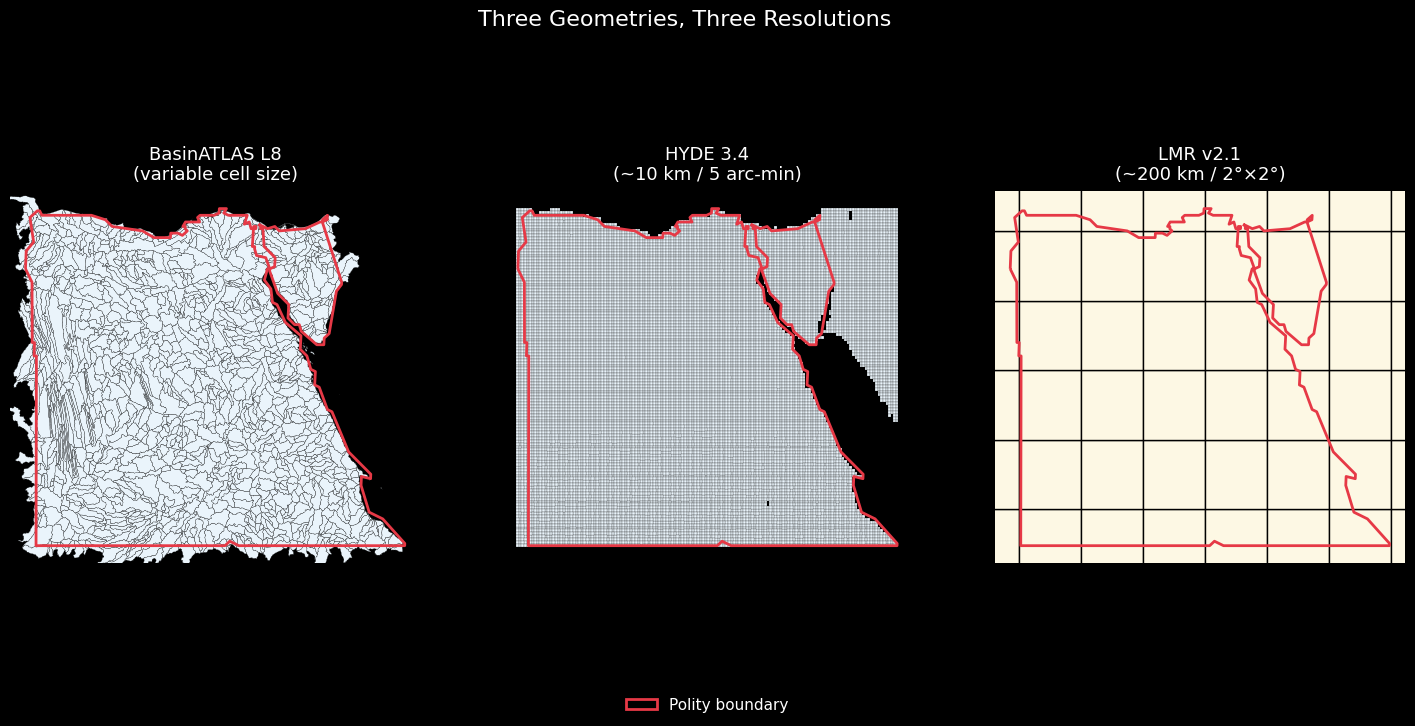

In [9]:
# Cell 9 — Figure 2: three geometries, three resolutions
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

panels = [
    ('BasinATLAS L8\n(variable cell size)', gdf_l8,   '#eaf4fb', 'black', 0.15),
    ('HYDE 3.4\n(~10 km / 5 arc-min)',      gdf_hyde, '#eaf4fb', 'black', 0.15),
    ('LMR v2.1\n(~200 km / 2°×2°)',          gdf_lmr,  '#fdf8e4', 'black', 1.0),
]

for ax, (title, gdf, fc, ec, lw) in zip(axes, panels):
    gdf.plot(ax=ax, facecolor=fc, edgecolor=ec, linewidth=lw)
    polity.boundary.plot(ax=ax, color=POLITY_COLOR, linewidth=POLITY_LW)
    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    ax.set_title(title, fontsize=13, pad=8)
    ax.set_axis_off()

legend_patch = mpatches.Patch(edgecolor=POLITY_COLOR, facecolor='none',
                               linewidth=POLITY_LW, label='Polity boundary')
fig.legend(handles=[legend_patch], loc='lower center', fontsize=11, frameon=False)
fig.suptitle('Three Geometries, Three Resolutions', fontsize=16, y=1.02)
plt.savefig(OUT / 'fig2_three_resolutions.png', dpi=300, bbox_inches='tight')
print('Saved fig2')

In [10]:
# Cell 10 — load HYDE cells intersecting polity (with overlap fraction) for pathway figure
gdf_hpoly = gpd.read_postgis(
    f"""
    SELECT hc.cell_id, hc.cropland, hc.area_km2, hc.geom,
           ST_Area(ST_Intersection(hc.geom, p.geom)::geography) /
           ST_Area(hc.geom::geography) AS frac_inside
    FROM temporal.hyde_cells hc
    JOIN gaz.clio_polities p ON p.id = {POLITY_ID}
    WHERE ST_Intersects(hc.geom, p.geom)
    """,
    conn, geom_col='geom'
).rename_geometry('geometry')

step_df = pd.read_sql(
    "SELECT step_idx FROM temporal.hyde_times ORDER BY ABS(year_ce - 1000) LIMIT 1", conn
)
step = int(step_df['step_idx'].iloc[0])
print(f'HYDE step_idx for ~1000 CE: {step}')

gdf_hpoly['cropland_val'] = gdf_hpoly['cropland'].apply(lambda arr: float(arr[step]) if arr else None)

pathway_b_mean = np.average(
    gdf_hpoly['cropland_val'],
    weights=gdf_hpoly['frac_inside'] * gdf_hpoly['area_km2']
)
print(f'Pathway B (whole-polity weighted mean): {pathway_b_mean:.4f}')

/var/folders/f9/r5mr431d23zcpktsjz_xjxt40000gn/T/ipykernel_79105/786659886.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  step_df = pd.read_sql(


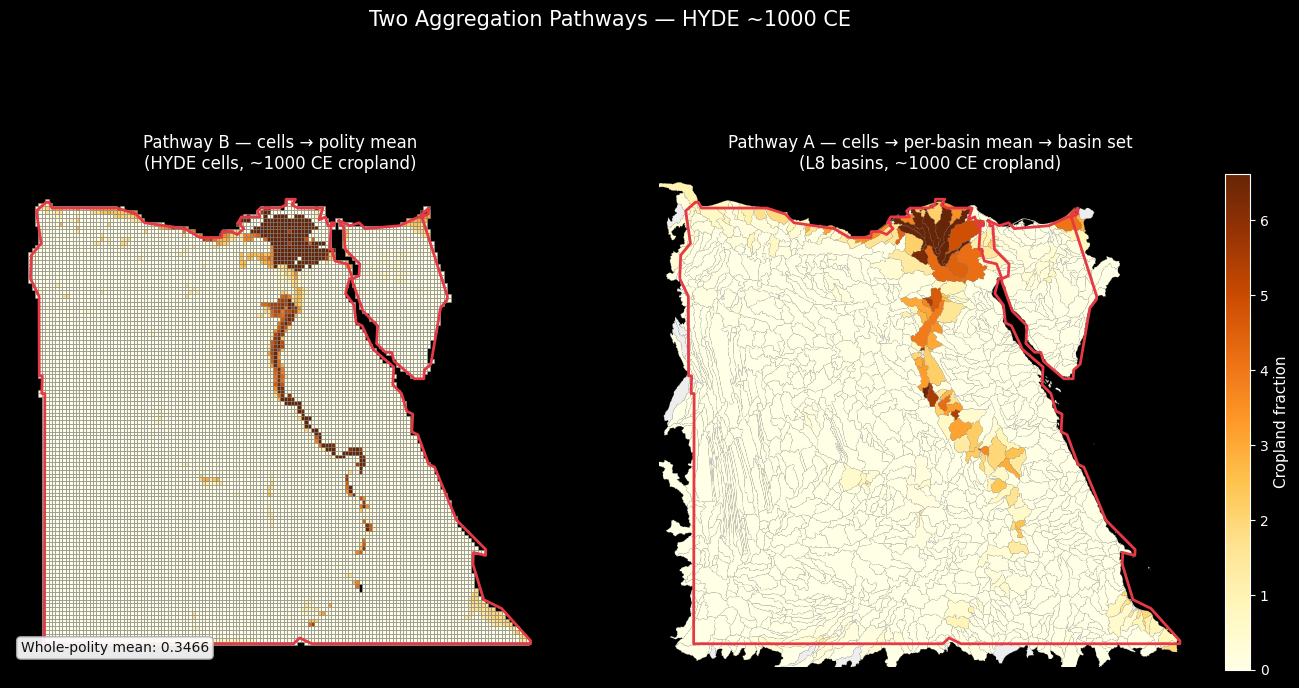

In [11]:
# Cell 11 — Figure 3: pathway comparison map
gdf_hpoly_pts = gdf_hpoly.copy()
gdf_hpoly_pts['geometry'] = gdf_hpoly_pts.geometry.centroid
joined = gpd.sjoin(
    gdf_hpoly_pts[['cropland_val','geometry']],
    gdf_l8[['hybas_id','geometry']],
    how='left', predicate='within'
)
basin_means = joined.groupby('hybas_id')['cropland_val'].mean().reset_index()
basin_means.columns = ['hybas_id', 'hyde_cropland_mean']
gdf_l8_a = gdf_l8.merge(basin_means, on='hybas_id', how='left')

vmax_crop = max(gdf_hpoly['cropland_val'].quantile(0.98), 0.01)
norm_crop = Normalize(vmin=0, vmax=vmax_crop)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax_b = axes[0]
gdf_hpoly.plot(column='cropland_val', ax=ax_b, cmap='YlOrBr', norm=norm_crop,
               edgecolor='#888', linewidth=0.4)
polity.boundary.plot(ax=ax_b, color=POLITY_COLOR, linewidth=POLITY_LW)
ax_b.set_xlim(minx - 0.5, maxx + 0.5)
ax_b.set_ylim(miny - 0.5, maxy + 0.5)
ax_b.set_title('Pathway B — cells → polity mean\n(HYDE cells, ~1000 CE cropland)', fontsize=12)
ax_b.set_axis_off()
ax_b.text(0.02, 0.03, f'Whole-polity mean: {pathway_b_mean:.4f}',
          transform=ax_b.transAxes, fontsize=10, color='#111111',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaaaaa', alpha=0.92))

ax_a = axes[1]
gdf_l8_a.plot(column='hyde_cropland_mean', ax=ax_a, cmap='YlOrBr', norm=norm_crop,
               edgecolor='#cccccc', linewidth=0.1,
               missing_kwds={'color': '#eeeeee', 'edgecolor': '#cccccc', 'label': 'No HYDE data'})
polity.boundary.plot(ax=ax_a, color=POLITY_COLOR, linewidth=POLITY_LW)
ax_a.set_xlim(minx - 0.5, maxx + 0.5)
ax_a.set_ylim(miny - 0.5, maxy + 0.5)
ax_a.set_title('Pathway A — cells → per-basin mean → basin set\n(L8 basins, ~1000 CE cropland)', fontsize=12)
ax_a.set_axis_off()

sm = ScalarMappable(cmap='YlOrBr', norm=norm_crop)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Cropland fraction', fontsize=11)

fig.suptitle('Two Aggregation Pathways — HYDE ~1000 CE', fontsize=15, y=1.01)
plt.savefig(OUT / 'fig3_aggregation_pathways.png', dpi=300, bbox_inches='tight')
print('Saved fig3')

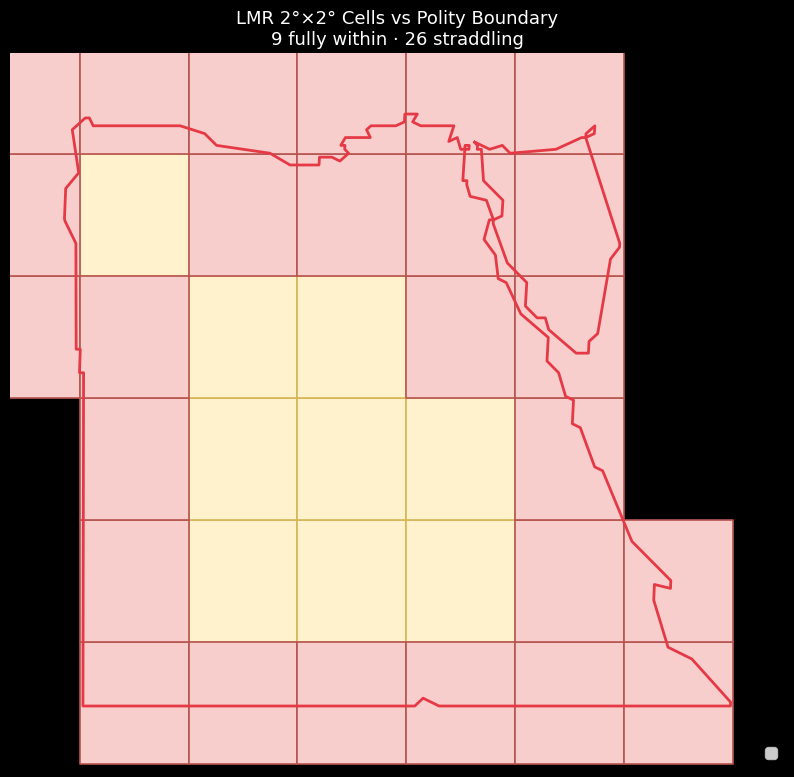

In [12]:
# Cell 12 — LMR resolution problem: cells straddling vs. within polity boundary
gdf_lmr_clip = gdf_lmr[gdf_lmr.intersects(polity_union)].copy()
gdf_lmr_clip['within'] = gdf_lmr_clip.within(polity_union)

n_within   = gdf_lmr_clip['within'].sum()
n_straddle = (~gdf_lmr_clip['within']).sum()
print(f'LMR cells fully within polity: {n_within}')
print(f'LMR cells straddling boundary: {n_straddle}')

fig, ax = plt.subplots(figsize=(10, 10))
gdf_lmr_clip[gdf_lmr_clip['within']].plot(
    ax=ax, facecolor='#fff2cc', edgecolor='#d6b656', linewidth=1.2, label='Fully within'
)
gdf_lmr_clip[~gdf_lmr_clip['within']].plot(
    ax=ax, facecolor='#f8cecc', edgecolor='#b85450', linewidth=1.2, label='Straddles boundary'
)
polity.boundary.plot(ax=ax, color=POLITY_COLOR, linewidth=POLITY_LW)
ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)
ax.set_title(
    f'LMR 2°×2° Cells vs Polity Boundary\n'
    f'{n_within} fully within · {n_straddle} straddling',
    fontsize=13
)
ax.set_axis_off()
ax.legend(fontsize=11, loc='lower right', frameon=True)
plt.savefig(OUT / 'fig3b_lmr_boundary.png', dpi=300, bbox_inches='tight')
print('Saved fig3b')

In [13]:
# Cell 13 — close connection
conn.close()
print('Done.')

Done.
